In [1]:
!pip install keras
!pip install tensorflow
!pip install autokeras
!pip install Pillow

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.python.keras.utils.data_utils import Sequence
import autokeras as ak
from matplotlib import pyplot as plt
from PIL import Image
from numpy import asarray
import os
from IPython.display import display
from IPython.display import Image as _Imgdis

In [3]:
def printImages(x, y, number):
    plt.imshow(x[number], interpolation='nearest')
    plt.show()
    print(y[number])

In [4]:
nr_images = 10000

In [5]:
folder = "../data/SolarPanelSoilingImageDataset/Solar_Panel_Soiling_Image_dataset/PanelImages"

onlyfiles = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]

In [6]:
onlyfiles = onlyfiles[0:nr_images]

In [7]:
print(len(onlyfiles))

10000


solar_Fri_Jun_16_10__12__44_2017_L_0.894957983193_I_0.2996.jpg


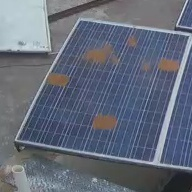

solar_Fri_Jun_16_10__12__49_2017_L_0.894957983193_I_0.2996.jpg


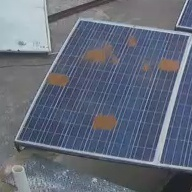

In [8]:
for i in range(40, 42):
    print(onlyfiles[i])
    display(_Imgdis(filename=folder + "/" + onlyfiles[i], width=240, height=320))

In [9]:
from scipy import ndimage
from keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img



train_files = []
y_train = np.ndarray(len(onlyfiles))
i=0


In [10]:
for _file in onlyfiles:
    train_files.append(_file)
    y_train[i] = (np.float64(_file.split('_')[11]))    
    i += 1
print("Files in train_files: %d" % len(train_files))

Files in train_files: 10000


In [11]:
_file.split('_')[11]

'0.0555077915099'

In [12]:
#float(_file[label_in_file_start+2:label_in_file_start+label_in_file_number+4])

In [13]:
# Original Dimensions
image_width = 192
image_height = 192
ratio = 1

image_width = int(image_width / ratio)
image_height = int(image_height / ratio)

channels = 3

dataset = np.ndarray(shape=(len(train_files), image_height, image_width, channels),
                     dtype=np.float32)

In [14]:
len(train_files)

10000

In [15]:
i = 0

for _file in train_files:
    img = load_img(folder + "/" + _file)  # this is a PIL image
    #img.thumbnail((image_width, image_height))
    # Convert to Numpy Array
    x = img_to_array(img)  
    #x = x.reshape((3, 48, 48))
    # Normalize
    #x = (x - 128.0) / 128.0
    dataset[i] = x
    i += 1
    if i % 250 == 0:
        print("%d images to array" % i)
print("All images to array!")

250 images to array
500 images to array
750 images to array
1000 images to array
1250 images to array
1500 images to array
1750 images to array
2000 images to array
2250 images to array
2500 images to array
2750 images to array
3000 images to array
3250 images to array
3500 images to array
3750 images to array
4000 images to array
4250 images to array
4500 images to array
4750 images to array
5000 images to array
5250 images to array
5500 images to array
5750 images to array
6000 images to array
6250 images to array
6500 images to array
6750 images to array
7000 images to array
7250 images to array
7500 images to array
7750 images to array
8000 images to array
8250 images to array
8500 images to array
8750 images to array
9000 images to array
9250 images to array
9500 images to array
9750 images to array
10000 images to array
All images to array!


In [19]:
from sklearn.model_selection import train_test_split

#Splitting 
X_train, X_test, y_train, y_test = train_test_split(dataset, y_train, test_size=0.2, random_state=33)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=33)
print("Train set size: {0}, Val set size: {1}, Test set size: {2}".format(len(X_train), len(X_val), len(X_test)))

Train set size: 8000, Val set size: 1000, Test set size: 1000


In [20]:
# Initialize the image regressor.
reg = ak.ImageRegressor(
    overwrite=True,
    max_trials=1)


In [21]:
X_train.shape

(8000, 192, 192, 3)

In [22]:
y_train.shape

(8000,)

In [23]:
# Feed the image regressor with training data.
reg.fit(X_train, 
        y_train, 
        validation_data=(X_val, y_val),
        batch_size=25,
        epochs=1)

Trial 1 Complete [00h 10m 31s]
val_loss: 10.697196960449219

Best val_loss So Far: 10.697196960449219
Total elapsed time: 00h 10m 31s
INFO:tensorflow:Oracle triggered exit
320/320 [==============================] - 584s 2s/step - loss: 26.5011 - mean_squared_error: 26.5011 - val_loss: 21.3000 - val_mean_squared_error: 21.3000
INFO:tensorflow:Assets written to: .\image_regressor\best_model\assets


In [24]:
reg.export_model()

In [26]:
# Predict with the best model.
predicted_y = reg.predict(X_test, batch_size=25)
print(predicted_y)



[[ 4.09391499e+00]
 [-1.22000909e+00]
 [ 2.28841138e+00]
 [ 2.43628788e+00]
 [ 4.74360609e+00]
 [ 3.01980090e+00]
 [ 3.39350533e+00]
 [ 7.61510551e-01]
 [ 5.32430029e+00]
 [ 5.58890867e+00]
 [ 2.66207039e-01]
 [ 4.76386118e+00]
 [ 2.22053623e+00]
 [ 8.69015336e-01]
 [ 4.42989206e+00]
 [ 4.18811464e+00]
 [ 1.78176379e+00]
 [-7.76010394e-01]
 [ 3.32179809e+00]
 [ 2.60576415e+00]
 [ 6.03358078e+00]
 [ 3.46321821e+00]
 [-5.20991445e-01]
 [ 1.66151547e+00]
 [ 5.21607935e-01]
 [ 3.20154572e+00]
 [ 1.22549903e+00]
 [ 3.05752802e+00]
 [ 3.88911891e+00]
 [ 4.05552435e+00]
 [ 1.63582706e+00]
 [ 5.08414888e+00]
 [ 1.49614370e+00]
 [ 5.65754747e+00]
 [ 3.37636256e+00]
 [-5.26348352e-01]
 [ 6.00022376e-01]
 [ 3.76273561e+00]
 [ 9.86317873e-01]
 [ 4.67922151e-01]
 [ 2.58801723e+00]
 [ 2.24280381e+00]
 [ 9.69661832e-01]
 [ 8.00483894e+00]
 [ 1.60687923e+00]
 [ 6.24134600e-01]
 [ 4.41314250e-01]
 [ 3.30385494e+00]
 [ 5.55607843e+00]
 [ 4.17370892e+00]
 [ 3.92325234e+00]
 [ 1.62763608e+00]
 [ 2.6329677

In [28]:
# Evaluate the best model with testing data.
best_model = reg.evaluate(X_test, y_test, batch_size=25, verbose=1)

40/40 [==============================] - 55s 1s/step - loss: 15.6543 - mean_squared_error: 15.6543


In [ ]:
best_model

In [ ]:
reg.metrics_names()

In [ ]:
help(reg)